Entropy versus entanglement-energy cutoff
Pure-state hard-wall endpoints, Nx=20, Ny=32, alpha1=1, cycle64; 100 independent trajectories, all 32 cut origins. No new dynamics or diagonalization.
Compute $S_E(A_y)=\sum_{|\epsilon_j|\le E}[-\nu_j\log\nu_j-(1-\nu_j)\log(1-\nu_j)]$, with $\epsilon=\log[(1-\nu)/\nu]$ and $E=\log[(1+L)/(1-L)]$. Evaluate directly in occupations, including the continuous zero-entropy limit at nu=0,1. This is an unnormalized entropy sum, not an entropy of a renormalized truncated state.
Average origins within each trajectory, then average trajectories. Fit $S_E=a_E+(c_{\rm eff}(E)/3)\log[(N_y/\pi)\sin(\pi A_y/N_y)]$. Errors are trajectory SEMs; paired comparisons preserve correlations across cuts and windows. This fixed-size fit is not a thermodynamic central-charge determination.

In [1]:
import os
CPU_RANGE=(40,43)
cpus=list(range(CPU_RANGE[0],CPU_RANGE[1]+1))
assert set(cpus).issubset(os.sched_getaffinity(0))
os.sched_setaffinity(0,cpus)
for key in ['OPENBLAS_NUM_THREADS','OMP_NUM_THREADS']:os.environ[key]='1'
print('CPU allocation:',cpus)

CPU allocation: [40, 41, 42, 43]


Configuration and verified input spectra
Window values are editable in analyze_entropy_windows.py. The full-entropy baseline uses every mode. Fits use Ay=5..16 and natural logarithms.

In [2]:
from pathlib import Path
import json,hashlib,shutil,subprocess
import numpy as np
import pandas as pd
from IPython.display import display,Image
from analyze_entropy_windows import analyze
OUT=Path.cwd()
table,diag=analyze()
print({k:diag[k] for k in ['Nx','Ny','samples','origins','cycles','windows','fit_widths','input_cache','input_sha256']})
with np.load(OUT/'entropy_window_statistics.npz') as z:
 coeff=z['trajectory_coefficients'];entropy=z['trajectory_entropy'];widths=z['widths'];x=z['log_chord']
L=table.L.to_numpy();E=np.full(len(L),np.inf);E[:-1]=np.log1p(L[:-1])-np.log1p(-L[:-1])
c=3*coeff[:,:,1];delta=c-c[:,-1,None]
table['energy_cutoff']=E;table['c_effective']=c.mean(0);table['c_effective_sem']=c.std(0,ddof=1)/10
table['c_minus_full']=delta.mean(0);table['c_minus_full_paired_sem']=delta.std(0,ddof=1)/10
rng=np.random.default_rng(2026100502);weights=rng.multinomial(100,np.full(100,.01),size=5000)/100
ci=np.quantile(weights@delta,[.025,.975],axis=0)
table['c_minus_full_ci95_low']=ci[0];table['c_minus_full_ci95_high']=ci[1]
table.to_csv(OUT/'entropy_cutoff_summary.csv',index=False)
# Independently reproduce the previously saved overlapping entropy fits.
prior=OUT.parent/'entropy_window_comparison_n20x32_v1'
manifest=json.loads((prior/'completion_manifest.json').read_text())
p=prior/'entropy_window_fits.csv';receipt=manifest['files'][p.name]
assert p.stat().st_size==receipt['bytes'] and hashlib.sha256(p.read_bytes()).hexdigest()==receipt['sha256']
old=pd.read_csv(p);maxdiff=0.
for row in old.itertuples():
 idx=np.flatnonzero(np.isclose(L,row.L,rtol=0,atol=1e-14))[0]
 maxdiff=max(maxdiff,abs(table.slope.iloc[idx]-row.slope),abs(table.half_entropy.iloc[idx]-row.half_entropy))
assert maxdiff<1e-10
# Continuum constant-density entropy kernel, used only as a benchmark anchored to the full entropy slope.
from scipy.integrate import quad
kernel=lambda e: np.log1p(np.exp(-e))+e*np.exp(-e)/(1+np.exp(-e))
grid=np.linspace(0,E[-2],300)
kernel_fraction=np.array([2*quad(kernel,0,e)[0]/(np.pi**2/3) for e in grid])
assert abs(2*quad(kernel,0,np.inf)[0]-np.pi**2/3)<1e-10
display(table[['L','energy_cutoff','c_effective','c_effective_sem','R_squared','half_entropy_retained_fraction']])

Entropy contributions by spectral window:   0%|          | 0/16 [00:00<?, ?width/s]

{'Nx': 20, 'Ny': 32, 'samples': 100, 'origins': 32, 'cycles': 64, 'windows': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 0.999, 0.9999, 0.99999, 1.0], 'fit_widths': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16], 'input_cache': '/home/abhuiyan/class_A_fermionic_adaptive_circuit/00_WORKSPACE/CURRENT/final_production_new_designs/09_pure_tangent_replay_acquisition/analysis_outputs/centered_spectral_window_origin_averaged_n20x32_hard_alpha1_v2/subsystem_spectra.npz', 'input_sha256': '8cd3aa2eee6df5a92d958f9df2025e530d9a3d62c9e33efb66c7fd129e71d260'}


,L,energy_cutoff,c_effective,c_effective_sem,R_squared,half_entropy_retained_fraction
0,0.10000,0.200671,0.079079,0.020891,0.591404,0.088702
1,0.20000,0.405465,0.167076,0.025043,0.933843,0.178909
2,0.30000,0.619039,0.301814,0.021336,0.967345,0.269429
3,0.40000,0.847298,0.330925,0.018563,0.992002,0.357356
4,0.50000,1.098612,0.447830,0.019923,0.991854,0.448349
5,0.60000,1.386294,0.572502,0.013777,0.995164,0.540408
6,0.70000,1.734601,0.669195,0.014360,0.999112,0.635138
7,0.80000,2.197225,0.774356,0.008239,0.999127,0.735040
8,0.90000,2.944439,0.897974,0.006908,0.999596,0.847402
9,0.95000,3.663562,0.972714,0.006208,0.999699,0.914325


Saturation with the energy cutoff
Left: measured entropy slopes and full-entropy baseline (one SEM band). The dotted line is the constant-density entropy-kernel prediction normalized to the measured full coefficient, not an independent fit. Right: missing half-system entropy fraction; errors from paired trajectory bootstrap. The full entropy is the E=infinity baseline, not a finite-cutoff point.

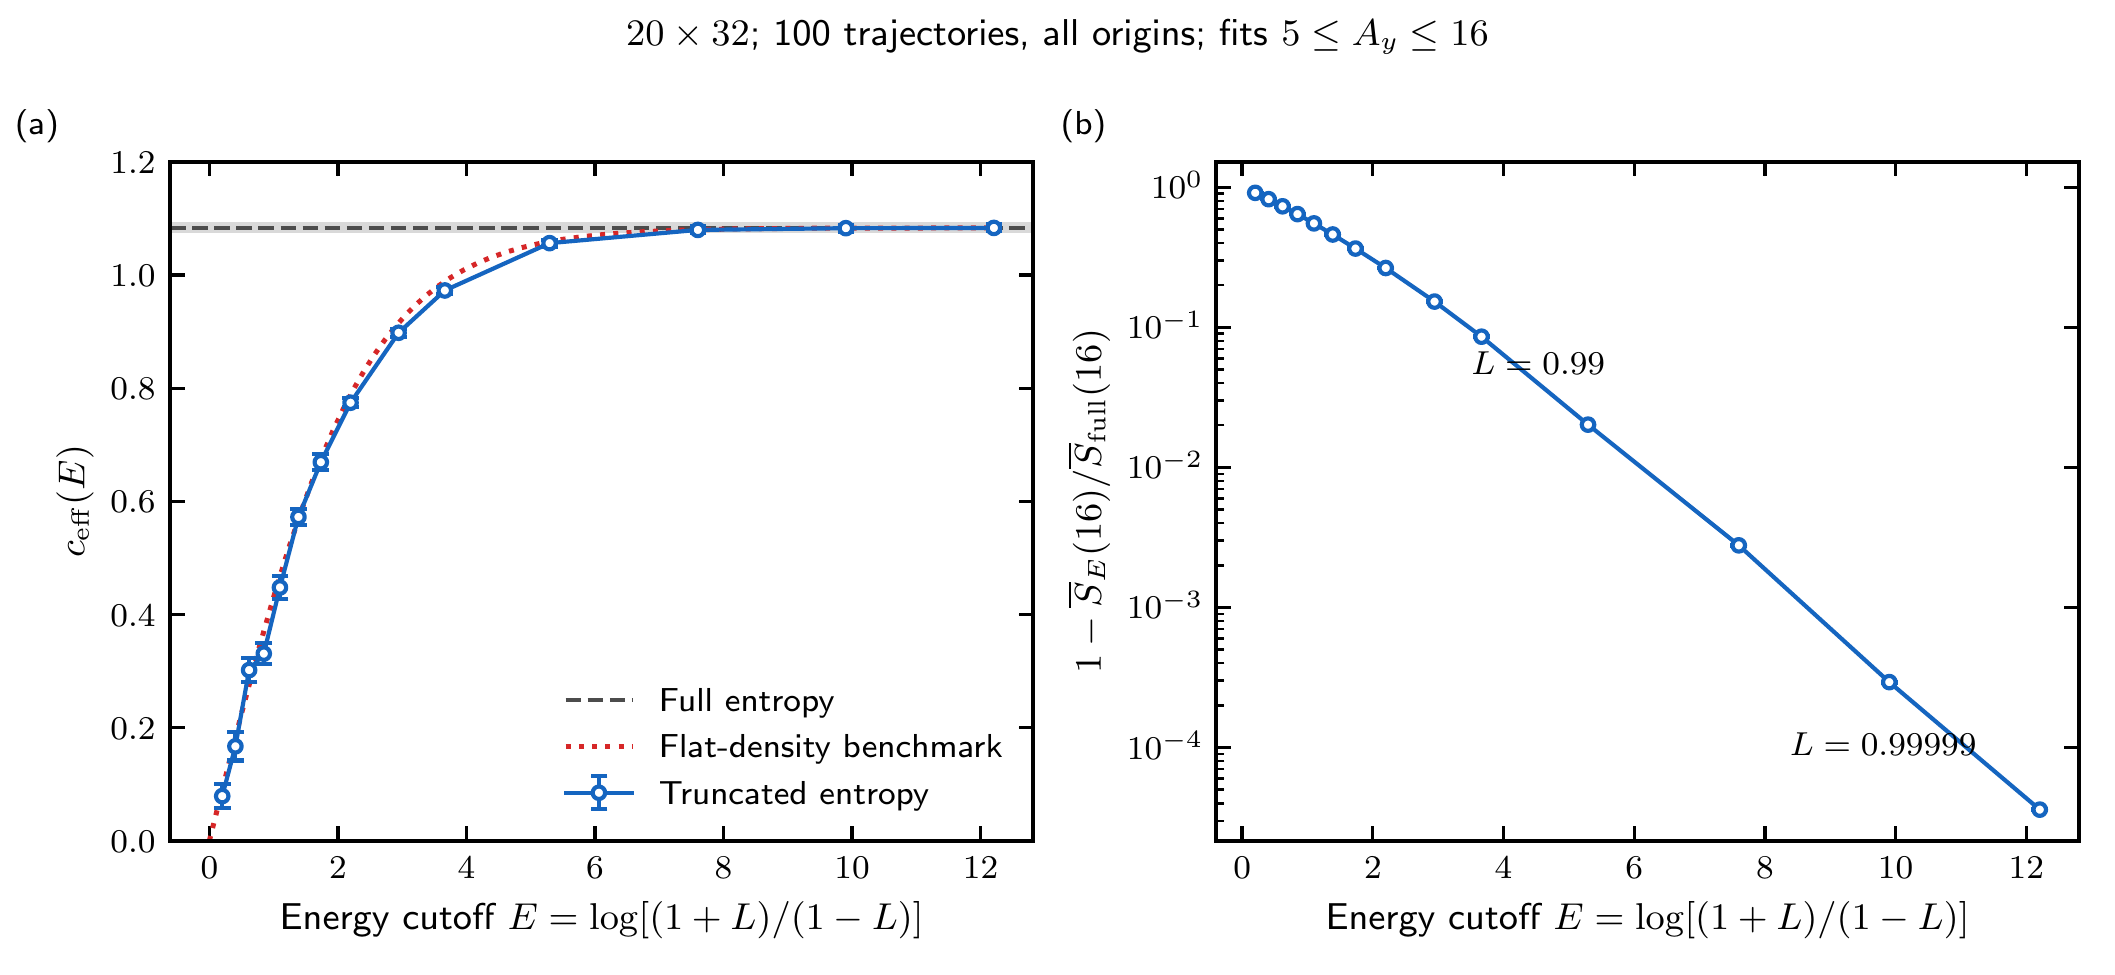

In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
shutil.copytree(prior/'latex_support',OUT/'latex_support',dirs_exist_ok=True)
os.environ['TEXINPUTS']=str(OUT/'latex_support')+os.pathsep+os.environ.get('TEXINPUTS','')
mpl.rcParams.update({'font.family':'sans-serif','font.sans-serif':['CMU Sans Serif'],'font.size':8,'axes.labelsize':9,'text.usetex':True,'text.latex.preamble':r'\usepackage{amsmath,amssymb}','xtick.direction':'in','ytick.direction':'in','legend.frameon':False,'legend.fontsize':8})
fig,axes=plt.subplots(1,2,figsize=(7.05,3.25))
full=table.c_effective.iloc[-1];err=table.c_effective_sem.iloc[-1]
axes[0].axhspan(full-err,full+err,color='.85',zorder=0)
axes[0].axhline(full,color='.3',ls='--',lw=1,label='Full entropy')
axes[0].plot(grid,full*kernel_fraction,':',color='#d62728',lw=1.2,label='Flat-density benchmark')
axes[0].errorbar(E[:-1],table.c_effective.iloc[:-1],yerr=table.c_effective_sem.iloc[:-1],fmt='o-',color='#1565c0',mfc='white',ms=3,lw=1,capsize=2,label='Truncated entropy')
axes[0].set(ylabel=r'$c_{\mathrm{eff}}(E)$',ylim=(0,1.2));axes[0].legend(loc='lower right')
missing=1-table.half_entropy_retained_fraction.to_numpy()[:-1]
boot=weights@entropy[:,:,-1];missing_boot=1-boot[:,:-1]/boot[:,-1,None]
low,high=np.quantile(missing_boot,[.025,.975],axis=0)
axes[1].errorbar(E[:-1],missing,yerr=[missing-low,high-missing],fmt='o-',color='#1565c0',mfc='white',ms=3,lw=1,capsize=2)
axes[1].set(yscale='log',ylabel=r'$1-\overline S_E(16)/\overline S_{\mathrm{full}}(16)$')
for idx,offset in [(10,(-28,12)),(13,(-60,13))]:
 axes[1].annotate(r'$L='+str(L[idx])+'$',(E[idx],missing[idx]),xytext=offset,textcoords='offset points',fontsize=8)
for ax,label in zip(axes,['(a)','(b)']):
 ax.set_xlabel(r'Energy cutoff $E=\log[(1+L)/(1-L)]$');ax.tick_params(top=True,right=True);ax.text(-.18,1.04,label,transform=ax.transAxes)
fig.suptitle(r'$20\times32$; 100 trajectories, all origins; fits $5\le A_y\le16$',fontsize=9)
fig.tight_layout();fig.savefig(OUT/'entropy_cutoff_convergence.pdf');plt.close(fig)
subprocess.run(['pdftoppm','-r','300','-singlefile','-png',str(OUT/'entropy_cutoff_convergence.pdf'),str(OUT/'entropy_cutoff_convergence')],check=True)
display(Image(filename=str(OUT/'entropy_cutoff_convergence.png'),width=1100))

Diagnostics and provenance
Entropy is nondecreasing under window enlargement; fitted slopes need not obey that property. The omitted entropy and paired slope differences are computed from the same trajectories. Bootstrap seed 2026100502, 5000 resamples. No flat-density assumption enters measured entropy or fits.

In [4]:
diag.update(full_c_effective=float(full),full_c_effective_sem=float(err),prior_overlap_max_difference=maxdiff,paired_bootstrap_seed=2026100502,paired_bootstrap_samples=5000,entropy_monotonic=bool(np.all(np.diff(entropy,axis=1)>=-1e-12)),coefficient_convention='S=a+c_eff/3 log(chord); no thermodynamic extrapolation',figure_uncertainties='left one SEM; right paired trajectory bootstrap 95% CI',summary=table.replace([np.inf], 'infinity').to_dict('records'))
(OUT/'diagnostics.json').write_text(json.dumps(diag,indent=2)+'\n')
print('Full-entropy c_eff:',full,'+/-',err,'(SEM)')
print('Prior overlapping entropy results maximum difference:',maxdiff)
print('Entropy monotonic:',diag['entropy_monotonic'])
print('COMPLETE')

Full-entropy c_eff: 1.0833524231474951 +/- 0.0059916737329636875 (SEM)
Prior overlapping entropy results maximum difference: 5.551115123125783e-17
Entropy monotonic: True
COMPLETE
